# 10: Properties of Digital Life

A tiny digital-substrate model for fork, merge, checkpoint, restore, and DAG ancestry. This is not a Python tutorial and not a life claim; it makes the chapter's native substrate primitives inspectable.


In [1]:
from pathlib import Path
import base64
import copy
import math
import sqlite3
from collections import Counter, defaultdict, deque
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
BOOK_FIG_DIR = ROOT / "static" / "images" / "books" / "digital-life"
FIG_DIR = ROOT / "notebooks" / "generated-figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 180


In [2]:
EXPERIMENT = {"start": "S", "operations": ["fork", "independent modification", "merge", "checkpoint", "restore"]}
EXPERIMENT


{'start': 'S',
 'operations': ['fork',
  'independent modification',
  'merge',
  'checkpoint',
  'restore']}

In [3]:
@dataclass
class Node:
    name: str
    parents: tuple
    memory: frozenset
    history: tuple

def fork(node, a, b):
    return (Node(a, (node.name,), node.memory, node.history + (a,)), Node(b, (node.name,), node.memory, node.history + (b,)))
def learn(node, item):
    return Node(node.name, node.parents, frozenset(set(node.memory) | {item}), node.history)
def merge(name, left, right):
    return Node(name, (left.name, right.name), frozenset(set(left.memory) | set(right.memory)), left.history + right.history + (name,))
S = Node("S", tuple(), frozenset({"K"}), ("S",))
checkpoint = copy.deepcopy(S)
S1, S2 = fork(S, "S1", "S2")
S1 = learn(S1, "A"); S2 = learn(S2, "B")
S3 = merge("S3", S1, S2)
restored = learn(Node("S_restore", (checkpoint.name,), checkpoint.memory, checkpoint.history + ("S_restore",)), "C")
[S, S1, S2, S3, restored]


[Node(name='S', parents=(), memory=frozenset({'K'}), history=('S',)),
 Node(name='S1', parents=('S',), memory=frozenset({'A', 'K'}), history=('S', 'S1')),
 Node(name='S2', parents=('S',), memory=frozenset({'B', 'K'}), history=('S', 'S2')),
 Node(name='S3', parents=('S1', 'S2'), memory=frozenset({'B', 'A', 'K'}), history=('S', 'S1', 'S', 'S2', 'S3')),
 Node(name='S_restore', parents=('S',), memory=frozenset({'K', 'C'}), history=('S', 'S_restore'))]

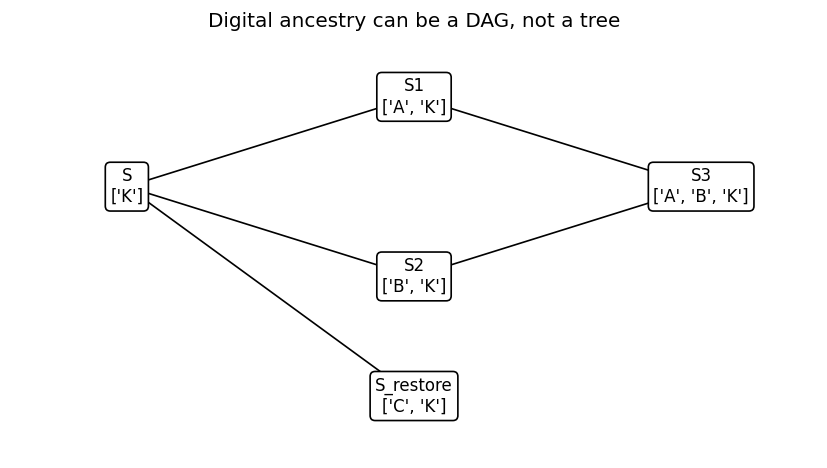

In [4]:
nodes = {n.name: n for n in [S, S1, S2, S3, restored]}
edges = [(p, n.name) for n in nodes.values() for p in n.parents]
fig, ax = plt.subplots(figsize=(7,4)); pos={"S":(0,1),"S1":(1,1.6),"S2":(1,.4),"S3":(2,1),"S_restore":(1,-.4)}
for a,b in edges: ax.annotate("", xy=pos[b], xytext=pos[a], arrowprops={"arrowstyle":"->"})
for name,(x,y) in pos.items(): ax.text(x,y, f"{name}\n{sorted(nodes[name].memory)}", ha="center", va="center", bbox={"boxstyle":"round,pad=.3","fc":"white","ec":"black"})
ax.set_xlim(-.4,2.4); ax.set_ylim(-.8,2); ax.axis("off"); ax.set_title("Digital ancestry can be a DAG, not a tree"); fig.tight_layout(); fig.savefig(FIG_DIR / "ch10-substrate-dag.png", bbox_inches="tight"); plt.show()


## Bounded conclusion

Forking creates two continuations with the same pre-fork history. Merging can transfer acquired information across branches. Checkpoint restoration creates another continuation from an earlier state. None of these operations imply life, but they are native digital possibilities that biological lineage does not map cleanly onto.

## Provenance

**Book chapter**: `content/books/digital-life/10-properties-of-digital-life/index.md`

**Research scripts used**: none; conceptual substrate model.

**Figures reproduced**: no checked-in book figure; notebook creates `ch10-substrate-dag.png`.
